WAP to find Precision , Recall , F1 Score for each class 
|        |   a |   b |   c |   d |
|--------|-----|-----|-----|-----|
| **a**  |  6  |  0  |  1  |  2  |
| **b**  |  3  |  9  |  1  |  1  |
| **c**  |  1  |  0  | 10  |  2  |
| **d**  |  1  |  2  |  1  | 12  |


Example Confusion Matrix

|         | Pred Yes | Pred No |
|---------|----------|---------|
| **Actual Yes** |   TP     |   FN    |
| **Actual No**  |   FP     |   TN    |


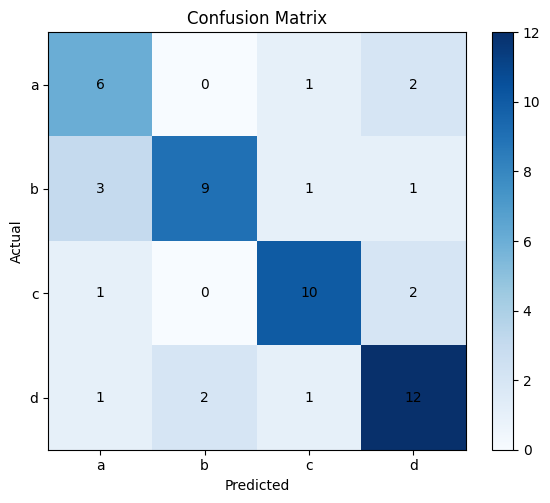

Class a
  TP=6, FP=5, FN=3, TN=38
  Precision = TP/(TP+FP) = 0.5455
  Recall    = TP/(TP+FN) = 0.6667
  F1 Score  = 2PR/(P+R)  = 0.6000

Class b
  TP=9, FP=2, FN=5, TN=36
  Precision = TP/(TP+FP) = 0.8182
  Recall    = TP/(TP+FN) = 0.6429
  F1 Score  = 2PR/(P+R)  = 0.7200

Class c
  TP=10, FP=3, FN=3, TN=36
  Precision = TP/(TP+FP) = 0.7692
  Recall    = TP/(TP+FN) = 0.7692
  F1 Score  = 2PR/(P+R)  = 0.7692

Class d
  TP=12, FP=5, FN=4, TN=31
  Precision = TP/(TP+FP) = 0.7059
  Recall    = TP/(TP+FN) = 0.7500
  F1 Score  = 2PR/(P+R)  = 0.7273



In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Confusion Matrix (rows = Actual, cols = Predicted)
cm = np.array([
    [6, 0, 1, 2],   # a
    [3, 9, 1, 1],   # b
    [1, 0, 10, 2],  # c
    [1, 2, 1, 12]   # d
])

classes = ["a", "b", "c", "d"]

# ------------------ PLOT FIRST ------------------
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")  # Changed color map to 'Blues'
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)

# Write numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")  # Changed text color to red

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ------------------ CALCULATIONS ------------------
n = cm.shape[0]

for i in range(n):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP      # column sum - TP
    FN = cm[i, :].sum() - TP      # row sum - TP
    TN = cm.sum() - (TP + FP + FN)

    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print(f"Class {classes[i]}")
    print(f"  TP={TP}, FP={FP}, FN={FN}, TN={TN}")
    print(f"  Precision = TP/(TP+FP) = {precision:.4f}")
    print(f"  Recall    = TP/(TP+FN) = {recall:.4f}")
    print(f"  F1 Score  = 2PR/(P+R)  = {f1:.4f}\n")


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

# Confusion Matrix
cm = np.array([
    [6, 0, 1, 2],
    [3, 9, 1, 1],
    [1, 0, 10, 2],
    [1, 2, 1, 12]
])

classes = ["a", "b", "c", "d"]

# Your big colormap list (trim if you want)
requested = [
 'magma','inferno','plasma','viridis','cividis','twilight','twilight_shifted','turbo',
 'Blues','BrBG','BuGn','BuPu','CMRmap','GnBu','Greens','Greys','OrRd','Oranges','PRGn','PiYG',
 'PuBu','PuBuGn','PuOr','PuRd','Purples','RdBu','RdGy','RdPu','RdYlBu','RdYlGn','Reds',
 'Spectral','Wistia','YlGn','YlGnBu','YlOrBr','YlOrRd','afmhot','autumn','binary','bone',
 'brg','bwr','cool','coolwarm','copper','cubehelix','flag','gist_earth','gist_gray',
 'gist_heat','gist_ncar','gist_rainbow','gist_stern','gist_yarg','gnuplot','gnuplot2',
 'gray','hot','hsv','jet','nipy_spectral','ocean','pink','prism','rainbow','seismic',
 'spring','summer','terrain','winter','Accent','Dark2','Paired','Pastel1','Pastel2',
 'Set1','Set2','Set3','tab10','tab20','tab20b','tab20c',
 'magma_r','inferno_r','plasma_r','viridis_r','cividis_r','twilight_r','twilight_shifted_r',
 'turbo_r','Blues_r','BrBG_r','BuGn_r','BuPu_r','CMRmap_r','GnBu_r','Greens_r','Greys_r',
 'OrRd_r','Oranges_r','PRGn_r','PiYG_r','PuBu_r','PuBuGn_r','PuOr_r','PuRd_r','Purples_r',
 'RdBu_r','RdGy_r','RdPu_r','RdYlBu_r','RdYlGn_r','Reds_r','Spectral_r','Wistia_r','YlGn_r',
 'YlGnBu_r','YlOrBr_r','YlOrRd_r','afmhot_r','autumn_r','binary_r','bone_r','brg_r','bwr_r',
 'cool_r','coolwarm_r','copper_r','cubehelix_r','flag_r','gist_earth_r','gist_gray_r',
 'gist_heat_r','gist_ncar_r','gist_rainbow_r','gist_stern_r','gist_yarg_r','gnuplot_r',
 'gnuplot2_r','gray_r','hot_r','hsv_r','jet_r','nipy_spectral_r','ocean_r','pink_r',
 'prism_r','rainbow_r','seismic_r','spring_r','summer_r','terrain_r','winter_r','Accent_r',
 'Dark2_r','Paired_r','Pastel1_r','Pastel2_r','Set1_r','Set2_r','Set3_r','tab10_r',
 'tab20_r','tab20b_r','tab20c_r'
]

available = set(plt.colormaps())
colormaps = [c for c in requested if c in available]

frames = []

for cmap in colormaps:
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.imshow(cm, cmap=cmap)
    ax.set_title(cmap, fontsize=8)
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

    fig.canvas.draw()
    buf = np.asarray(fig.canvas.buffer_rgba())
    img = buf[:, :, :3]   # drop alpha channel

    frames.append(img)
    plt.close(fig)

imageio.mimsave("confusion_matrix_colormaps.gif", frames, duration=0.1)
print("Saved as confusion_matrix_colormaps.gif")


Saved as confusion_matrix_colormaps.gif
